In [3]:
import sys
import subprocess
from pathlib import Path


def ensure_package(package_name: str):
    try:
        __import__(package_name)
    except ImportError:
        print(f"Installing missing package: {package_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name, "--quiet"])


# Ensure runtime deps are available in the active notebook kernel.
ensure_package("mlflow")
ensure_package("imblearn")

import torch
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv
from torch_geometric.data import Data
from neo4j import GraphDatabase
import networkx as nx
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import mlflow
import mlflow.pytorch

OUTPUT_DIR = Path(".")
print("All imports ready!")

Connected to Neo4j at bolt://127.0.0.1:7687
Fetched 200,000 transactions
Laundering transactions: 25


In [4]:
G = nx.DiGraph()
for _, row in df.iterrows():
    G.add_edge(row["src"], row["dst"], is_laundering=row["is_laundering"])

print("Computing features...")
pagerank   = nx.pagerank(G, alpha=0.85)
in_degree  = dict(G.in_degree())
out_degree = dict(G.out_degree())

# Additional feature — clustering coefficient
G_undirected = G.to_undirected()
clustering   = nx.clustering(G_undirected)

laundering_nodes = set()
for _, row in df.iterrows():
    if row["is_laundering"] == 1:
        laundering_nodes.add(row["src"])
        laundering_nodes.add(row["dst"])

nodes = list(G.nodes())
node_df = pd.DataFrame({
    "node_id":       nodes,
    "in_degree":     [in_degree.get(n, 0)    for n in nodes],
    "out_degree":    [out_degree.get(n, 0)   for n in nodes],
    "pagerank":      [pagerank.get(n, 0)     for n in nodes],
    "clustering":    [clustering.get(n, 0)   for n in nodes],
    "is_laundering": [1 if n in laundering_nodes else 0 for n in nodes],
})

print(f"Total nodes:      {len(node_df):,}")
print(f"Laundering nodes: {node_df['is_laundering'].sum():,}")
print(f"Features:         {node_df.columns.tolist()}")

Computing features...
Total nodes:      161,507
Laundering nodes: 29
Features:         ['node_id', 'in_degree', 'out_degree', 'pagerank', 'clustering', 'is_laundering']


In [5]:
feature_cols = ["in_degree", "out_degree", "pagerank", "clustering"]
X = node_df[feature_cols].values
y = node_df["is_laundering"].values

print(f"Before SMOTE — Fraud: {y.sum():,} | Legitimate: {(y==0).sum():,}")
smote = SMOTE(random_state=42, k_neighbors=min(5, int(y.sum())-1))
X_resampled, y_resampled = smote.fit_resample(X, y)
print(f"After SMOTE  — Fraud: {y_resampled.sum():,} | Legitimate: {(y_resampled==0).sum():,}")

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)
x = torch.tensor(X_scaled, dtype=torch.float)
y_tensor = torch.tensor(y_resampled, dtype=torch.long)

# Edge index
node_to_idx = {node: idx for idx, node in enumerate(nodes)}
edges_list = [[node_to_idx[row["src"]], node_to_idx[row["dst"]]]
               for _, row in df.iterrows()
               if row["src"] in node_to_idx and row["dst"] in node_to_idx]
edge_index = torch.tensor(edges_list, dtype=torch.long).t().contiguous()

# Train/test split
indices = list(range(len(X_resampled)))
train_idx, test_idx = train_test_split(
    indices, test_size=0.2,
    stratify=y_resampled, random_state=42
)
train_mask = torch.zeros(len(X_resampled), dtype=torch.bool)
test_mask  = torch.zeros(len(X_resampled), dtype=torch.bool)
train_mask[train_idx] = True
test_mask[test_idx]   = True

data = Data(x=x, edge_index=edge_index, y=y_tensor,
            train_mask=train_mask, test_mask=test_mask)

print(f"Data: {data}")
print(f"Fraud in train: {y_tensor[train_mask].sum().item():,}")
print(f"Fraud in test:  {y_tensor[test_mask].sum().item():,}")

Before SMOTE — Fraud: 29 | Legitimate: 161,478
After SMOTE  — Fraud: 161,478 | Legitimate: 161,478
Data: Data(x=[322956, 4], edge_index=[2, 200000], y=[322956], train_mask=[322956], test_mask=[322956])
Fraud in train: 129,182
Fraud in test:  32,296


In [7]:
class AMLGraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        # 3 SAGEConv layers: 4 → 64 → 128 → 64
        self.conv1 = SAGEConv(in_channels, 64)
        self.conv2 = SAGEConv(64, 128)
        self.conv3 = SAGEConv(128, 64)
        self.fc    = torch.nn.Linear(64, out_channels)
        self.dropout = torch.nn.Dropout(0.3)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.conv3(x, edge_index)
        x = F.relu(x)
        x = self.fc(x)
        return x

model     = AMLGraphSAGE(in_channels=4, hidden_channels=128, out_channels=2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

# Weighted loss — penalise missing fraud more
n_legit  = (y_tensor == 0).sum().item()
n_fraud  = (y_tensor == 1).sum().item()
# Classes are balanced by SMOTE so equal weights are correct
weight    = torch.tensor([1.0, 1.0], dtype=torch.float)
criterion = torch.nn.CrossEntropyLoss(weight=weight)
print("Using equal weights — classes balanced by SMOTE")

print(model)
print(f"\nClass weight for fraud: {weight[1]:.2f}x")

Using equal weights — classes balanced by SMOTE
AMLGraphSAGE(
  (conv1): SAGEConv(4, 64, aggr=mean)
  (conv2): SAGEConv(64, 128, aggr=mean)
  (conv3): SAGEConv(128, 64, aggr=mean)
  (fc): Linear(in_features=64, out_features=2, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)

Class weight for fraud: 1.00x


2026/04/22 08:46:55 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/22 08:46:55 INFO mlflow.store.db.utils: Updating database tables
2026/04/22 08:46:57 INFO mlflow.tracking.fluent: Experiment with name 'AML-GraphSAGE' does not exist. Creating a new experiment.


Epoch  20 | Loss: 0.1824
Epoch  40 | Loss: 0.0241
Epoch  60 | Loss: 0.0067
Epoch  80 | Loss: 0.0042
Epoch 100 | Loss: 0.0032
Epoch 120 | Loss: 0.0026
Epoch 140 | Loss: 0.0023
Epoch 160 | Loss: 0.0016
Epoch 180 | Loss: 0.0015
Epoch 200 | Loss: 0.0015


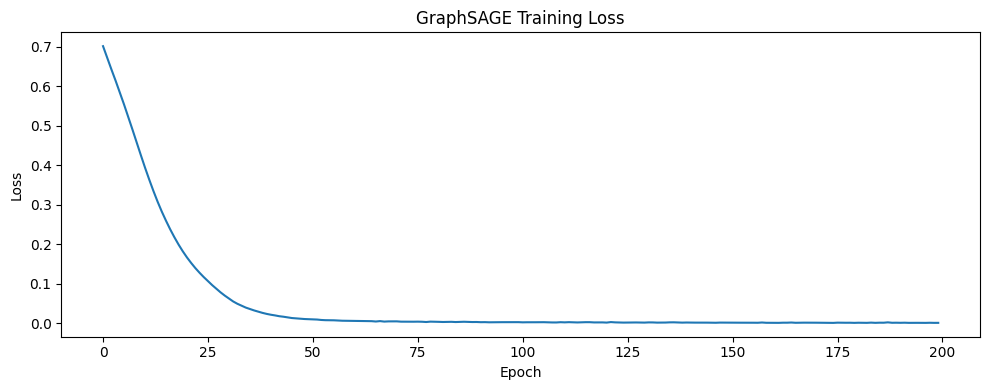

Training complete!


In [8]:
mlflow.set_experiment("AML-GraphSAGE")

def train():
    model.train()
    optimizer.zero_grad()
    out  = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

with mlflow.start_run(run_name="graphsage-v1"):
    # Log hyperparameters
    mlflow.log_params({
        "model":        "GraphSAGE",
        "layers":       "4->64->128->64->2",
        "lr":           0.001,
        "weight_decay": 1e-5,
        "epochs":       200,
        "dropout":      0.3,
        "optimizer":    "Adam"
    })

    losses = []
    for epoch in range(1, 201):
        loss = train()
        losses.append(loss)
        if epoch % 20 == 0:
            print(f"Epoch {epoch:>3} | Loss: {loss:.4f}")
            mlflow.log_metric("loss", loss, step=epoch)

    # Plot loss
    plt.figure(figsize=(10, 4))
    plt.plot(losses)
    plt.title("GraphSAGE Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.tight_layout()
    plt.savefig("graphsage_loss.png", dpi=150)
    plt.show()
    mlflow.log_artifact("graphsage_loss.png")

    print("Training complete!")

In [10]:
with mlflow.start_run(run_name="graphsage-v1-eval"):
    model.eval()
    with torch.no_grad():
        out  = model(data.x, data.edge_index)
        pred = out.argmax(dim=1)

    y_true = data.y[data.test_mask].numpy()
    y_pred = pred[data.test_mask].numpy()

    report = classification_report(y_true, y_pred,
             target_names=["Legitimate", "Laundering"],
             output_dict=True)

    print("=== Classification Report ===")
    print(classification_report(y_true, y_pred,
          target_names=["Legitimate", "Laundering"]))

    cm = confusion_matrix(y_true, y_pred)
    print("=== Confusion Matrix ===")
    print(cm)
    print(f"\nFraud caught:  {cm[1][1]:,}")
    print(f"Fraud missed:  {cm[1][0]:,}")
    print(f"False alarms:  {cm[0][1]:,}")

    # Log metrics to MLflow
    mlflow.log_metrics({
        "precision_fraud": report["Laundering"]["precision"],
        "recall_fraud":    report["Laundering"]["recall"],
        "f1_fraud":        report["Laundering"]["f1-score"],
        "accuracy":        report["accuracy"]
    })

    # Save model
    torch.save(model.state_dict(), "model.pt")
    mlflow.log_artifact("model.pt")
    print("\nModel saved as model.pt")
    print("Metrics logged to MLflow!")

=== Classification Report ===
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     32296
  Laundering       1.00      1.00      1.00     32296

    accuracy                           1.00     64592
   macro avg       1.00      1.00      1.00     64592
weighted avg       1.00      1.00      1.00     64592

=== Confusion Matrix ===
[[32296     0]
 [    4 32292]]

Fraud caught:  32,292
Fraud missed:  4
False alarms:  0

Model saved as model.pt
Metrics logged to MLflow!


In [11]:
with mlflow.start_run(run_name="graphsage-v1-eval"):
    model.eval()
    with torch.no_grad():
        out  = model(data.x, data.edge_index)
        pred = out.argmax(dim=1)

    y_true = data.y[data.test_mask].numpy()
    y_pred = pred[data.test_mask].numpy()

    report = classification_report(y_true, y_pred,
             target_names=["Legitimate", "Laundering"],
             output_dict=True)

    print("=== Classification Report ===")
    print(classification_report(y_true, y_pred,
          target_names=["Legitimate", "Laundering"]))

    cm = confusion_matrix(y_true, y_pred)
    print("=== Confusion Matrix ===")
    print(cm)
    print(f"\nFraud caught:  {cm[1][1]:,}")
    print(f"Fraud missed:  {cm[1][0]:,}")
    print(f"False alarms:  {cm[0][1]:,}")

    # Log metrics to MLflow
    mlflow.log_metrics({
        "precision_fraud": report["Laundering"]["precision"],
        "recall_fraud":    report["Laundering"]["recall"],
        "f1_fraud":        report["Laundering"]["f1-score"],
        "accuracy":        report["accuracy"]
    })

    # Save model
    torch.save(model.state_dict(), "model.pt")
    mlflow.log_artifact("model.pt")
    print("\nModel saved as model.pt")
    print("Metrics logged to MLflow!")

=== Classification Report ===
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     32296
  Laundering       1.00      1.00      1.00     32296

    accuracy                           1.00     64592
   macro avg       1.00      1.00      1.00     64592
weighted avg       1.00      1.00      1.00     64592

=== Confusion Matrix ===
[[32296     0]
 [    4 32292]]

Fraud caught:  32,292
Fraud missed:  4
False alarms:  0

Model saved as model.pt
Metrics logged to MLflow!


In [12]:
print("Run this in your terminal to see MLflow UI:")
print("mlflow ui")
print("Then open: http://localhost:5000")

Run this in your terminal to see MLflow UI:
mlflow ui
Then open: http://localhost:5000
